# Healthcare Popular Times Proxy Busyness ML

本 notebook 只负责运行 pipeline、展示结果、输出图表和说明。数据构建逻辑已经拆到：

```text
Data+ML/test/6.28-7.3/src/ml_feature_pipeline.py
```

目标仍是预测 `Google Popular Times proxy busyness`，不是实测真实客流。

`rating` 现在由 SerpAPI Place results 回填到 `venues.rating`，回填完成后会在覆盖统计里重新出现。

当前特征输入优先来自 DB 规范化表（`venues`、`healthcare_profiles`、`pedestrian_ramps`），`venue_label_status_coverage_view.csv` 只保留样本锚点和覆盖统计。


## 0. Notebook 职责

- 运行离线 pipeline 生成/刷新 CSV 输出。
- 展示标签覆盖、特征覆盖、外部数据源审计、训练表规模。
- 展示输入指标与输出指标说明。
- 展示 DB 直取字段、外部静态 enrich 字段和 label-only 字段的来源归类。
- 不调用 SerpAPI live API，不写 DB，不执行 schema migration。
- 保留少量图表，方便汇报和检查。


In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'Data+ML').exists() and (candidate / 'docs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
PIPELINE_SRC = PROJECT_ROOT / 'Data+ML/test/6.28-7.3/src'
OUTPUT_DIR = PROJECT_ROOT / 'Data+ML/test/6.28-7.3/output'

sys.path.insert(0, str(PIPELINE_SRC))
from ml_feature_pipeline import run_pipeline

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PIPELINE_SRC exists:', PIPELINE_SRC.exists())
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_ROOT: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project
PIPELINE_SRC exists: True
OUTPUT_DIR: /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output


## 1. 运行 Pipeline

该步骤会读取本地静态数据、DB 导出的规范化表和 SerpAPI cache，并刷新 `output/` 下的 CSV。默认不调用外部 API。


In [2]:
outputs = run_pipeline(PROJECT_ROOT)
manifest = pd.read_csv(outputs['manifest'])
manifest


,name,path,rows
0,status_breakdown,/Users/alex/Documents/COMP47360-Research_Pract...,3
1,coverage_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
2,feature_registry,/Users/alex/Documents/COMP47360-Research_Pract...,40
3,popular_times,/Users/alex/Documents/COMP47360-Research_Pract...,16090
4,popular_times_summary,/Users/alex/Documents/COMP47360-Research_Pract...,1
5,place_features,/Users/alex/Documents/COMP47360-Research_Pract...,490
6,spatial_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
7,spatial_audit,/Users/alex/Documents/COMP47360-Research_Pract...,3
8,urban_activity_features,/Users/alex/Documents/COMP47360-Research_Pract...,1086
9,urban_activity_audit,/Users/alex/Documents/COMP47360-Research_Pract...,1


## 2. 读取输出结果


In [3]:

def read_output(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT_DIR / name, low_memory=False)

coverage_summary = read_output('coverage_summary.csv')
label_status = read_output('label_status_breakdown.csv')
feature_registry = read_output('feature_registry.csv')
popular_times_summary = read_output('popular_times_summary.csv')
training_summary = read_output('training_frame_summary.csv')
feature_coverage = read_output('feature_coverage_summary.csv')
training_row_feature_coverage = read_output('training_row_feature_coverage_summary.csv')
venue_feature_coverage = read_output('venue_static_feature_coverage_summary.csv')
spatial_audit = read_output('spatial_features_v1_audit.csv')
source_audit = read_output('healthcare_external_source_audit_v1.csv')
db_feature_source_audit = read_output('db_feature_source_audit.csv')
capacity_match_audit = read_output('healthcare_external_match_audit_v1.csv')
io_dictionary = read_output('input_output_field_dictionary.csv')
training_frame = read_output('ml_training_frame_v1.csv')
seasonal_baseline = read_output('seasonal_baseline.csv')
model_metrics = read_output('model_metrics_v1.csv')
model_predictions = read_output('model_test_predictions_v1.csv')
prediction_curve = read_output('prediction_curve_v1.csv')
ablation_summary = read_output('ablation_summary_v1.csv')
low_coverage_imputation = read_output('low_coverage_imputation_diagnostics_v1.csv')
low_coverage_drop_one = read_output('low_coverage_drop_one_ablation_v1.csv')

print('loaded outputs from', OUTPUT_DIR)


loaded outputs from /Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output


## 3. 标签覆盖与训练规模


In [4]:
display(coverage_summary)
display(popular_times_summary)
display(training_summary)
if {'metric', 'value'}.issubset(coverage_summary.columns):
    healthcare_positive = int(coverage_summary.loc[coverage_summary['metric'].eq('healthcare_has_popular_times'), 'value'].iloc[0])
else:
    healthcare_positive = int(coverage_summary['has_popular_times'].iloc[0])

if {'metric', 'value'}.issubset(popular_times_summary.columns):
    unique_groups = int(popular_times_summary.loc[popular_times_summary['metric'].eq('unique_prediction_groups'), 'value'].iloc[0])
else:
    unique_groups = int(popular_times_summary['unique_prediction_groups'].iloc[0])
print(f"{healthcare_positive}: healthcare venues labeled as has_popular_times")
print(f"{unique_groups}: unique SerpAPI place IDs with parseable hourly popular-times data")


,healthcare_total,serpapi_matched,has_popular_times,no_popular_times,search_not_matched,trainable_pct
0,1086,743,161,582,343,14.8


,json_files_with_rows,hourly_rows,unique_prediction_groups,min_hour,max_hour,busyness_min,busyness_max
0,130,16090,121,0,23,0,100


,metric,value
0,training_rows,22645
1,unique_prediction_groups,121
2,unique_venues,164
3,busyness_score_min,0
4,busyness_score_max,100
5,split_rows_train,15823
6,split_rows_val,3774
7,split_rows_test,3048


161: healthcare venues labeled as has_popular_times
121: unique SerpAPI place IDs with parseable hourly popular-times data


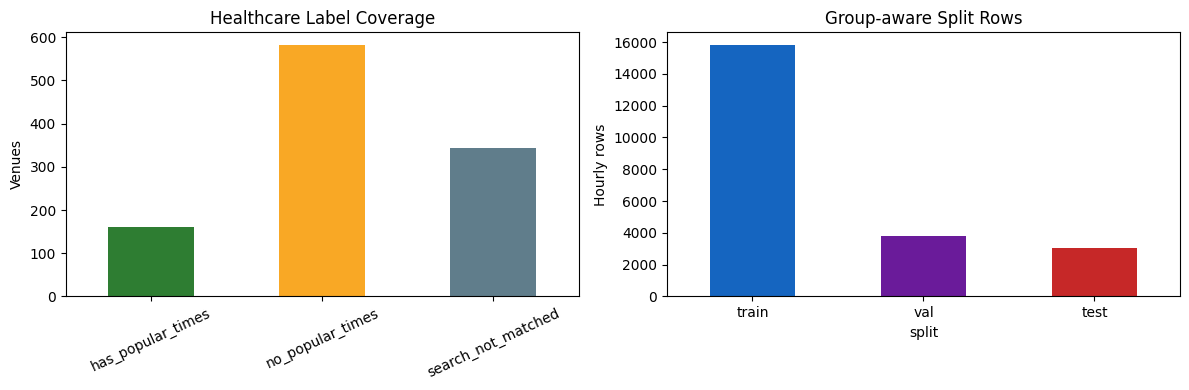

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

healthcare_counts = coverage_summary.iloc[0][['has_popular_times', 'no_popular_times', 'search_not_matched']]
healthcare_counts.plot(kind='bar', ax=axes[0], color=['#2E7D32', '#F9A825', '#607D8B'])
axes[0].set_title('Healthcare Label Coverage')
axes[0].set_ylabel('Venues')
axes[0].tick_params(axis='x', rotation=25)

split_counts = training_frame['split'].value_counts().reindex(['train', 'val', 'test']).fillna(0)
split_counts.plot(kind='bar', ax=axes[1], color=['#1565C0', '#6A1B9A', '#C62828'])
axes[1].set_title('Group-aware Split Rows')
axes[1].set_ylabel('Hourly rows')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


## 4. 特征登记与覆盖率

主覆盖率表 `feature_coverage_summary.csv` 只包含 `feature_registry.csv` 中登记的模型/输入特征。`input_output_field_dictionary.csv` 是更宽的全链路字段字典，包含 key、target、output、serving 和 audit 字段，不全部进入模型特征覆盖率。

每个特征按自身 `scope` 选择正确分母：

- `venue_static`: 分母是一行一个 healthcare venue。
- `training_row`: 分母是 `venue × day × hour` 的训练样本行。

`release_stage` 用来区分当前 V1 已实现/可用特征和 V2 规划特征：

- `V1`: 当前 pipeline 已实现并可用于 baseline / full_available 模型或 serving 约束。
- `V2`: 时间、天气、实时交通、实时容量、用户报告等动态特征规划项；当前通常显示为 `missing_column`，用于明确后续模型输入范围。

当前 V1 动态/时间特征包括：`day_of_week`、`hour`、`is_weekend`、`is_business_hours`。V2 动态特征包括 hourly mobility、weather、transit disruption、recent user reports 和 live capacity / wait-time signals。

`venue_static_feature_coverage_summary.csv` 和 `training_row_feature_coverage_summary.csv` 是诊断明细，用于分别查看 venue 级和 training-row 级字段覆盖率。


In [6]:
# 主表：严格限制为 feature_registry 中登记的模型/输入特征，并标注 V1 / V2 范围。
feature_display_cols = [
    'feature', 'release_stage', 'group', 'priority', 'scope',
    'dtype', 'non_null_rows', 'total_rows', 'coverage_pct', 'status', 'source_column'
]
available_display_cols = [col for col in feature_display_cols if col in feature_coverage.columns]
display(
    feature_coverage[available_display_cols]
    .sort_values(['release_stage', 'scope', 'coverage_pct'], ascending=[True, True, False])
)

print('Diagnostic: venue static coverage detail')
display(venue_feature_coverage.sort_values('coverage_pct', ascending=False))

print('Diagnostic: dynamic / temporal feature coverage detail')
display(training_row_feature_coverage.sort_values('coverage_pct', ascending=False))


,feature,release_stage,group,priority,scope,dtype,non_null_rows,total_rows,coverage_pct,status,source_column
0,day_of_week,V1,Temporal,P0,training_row,category,22645,22645,100.0,ok,day_of_week
1,hour,V1,Temporal,P0,training_row,int,22645,22645,100.0,ok,hour
2,is_weekend,V1,Temporal,P0,training_row,bool,22645,22645,100.0,ok,is_weekend
9,traffic_score,V1,SerpAPI,P0,training_row,int,22645,22645,100.0,ok,busyness_score
15,is_business_hours,V1,Derived,P0,training_row,bool,22645,22645,100.0,ok,is_business_hours
4,district,V1,DB direct,P0,venue_static,category,1086,1086,100.0,ok,district
6,healthcare_subtype,V1,DB direct,P0,venue_static,category,1086,1086,100.0,ok,healthcare_subtype
10,nearest_subway_distance_m,V1,Spatial,P1,venue_static,float,1086,1086,100.0,ok,nearest_subway_distance_m
11,nearest_citibike_distance_m,V1,Spatial,P1,venue_static,float,1086,1086,100.0,ok,nearest_citibike_distance_m
12,poi_density_300m,V1,Spatial,P1,venue_static,int,1086,1086,100.0,ok,poi_density_300m


Diagnostic: venue static coverage detail


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status
27,urban_activity_spatial_score,venue_static,float,1086,1086,100.0,ok
1,district,venue_static,category,1086,1086,100.0,ok
26,traffic_covered_500m,venue_static,float,1086,1086,100.0,ok
25,mta_covered_200m,venue_static,float,1086,1086,100.0,ok
4,healthcare_subtype,venue_static,category,1086,1086,100.0,ok
24,citibike_covered_200m,venue_static,float,1086,1086,100.0,ok
23,traffic_nearest_distance_m,venue_static,float,1086,1086,100.0,ok
22,mta_nearest_distance_m,venue_static,float,1086,1086,100.0,ok
21,citibike_nearest_distance_m,venue_static,float,1086,1086,100.0,ok
9,nearest_subway_distance_m,venue_static,float,1086,1086,100.0,ok


Diagnostic: dynamic / temporal feature coverage detail


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status,coverage_basis,source_column
0,day_of_week,training_row,category,22645,22645,100.0,ok,training row,day_of_week
2,is_weekend,training_row,bool,22645,22645,100.0,ok,training row,is_weekend
3,traffic_score,training_row,int,22645,22645,100.0,ok,training row,busyness_score
4,is_business_hours,training_row,bool,22645,22645,100.0,ok,training row,is_business_hours
1,hour,training_row,int,22645,22645,100.0,ok,training row,hour
11,weather_condition,training_row,missing,0,22645,0.0,missing_column,training row,weather_condition
16,recent_user_report_count,training_row,missing,0,22645,0.0,missing_column,training row,recent_user_report_count
15,transit_disruption_count,training_row,missing,0,22645,0.0,missing_column,training row,transit_disruption_count
14,heat_alert,training_row,missing,0,22645,0.0,missing_column,training row,heat_alert
13,temperature_c,training_row,missing,0,22645,0.0,missing_column,training row,temperature_c


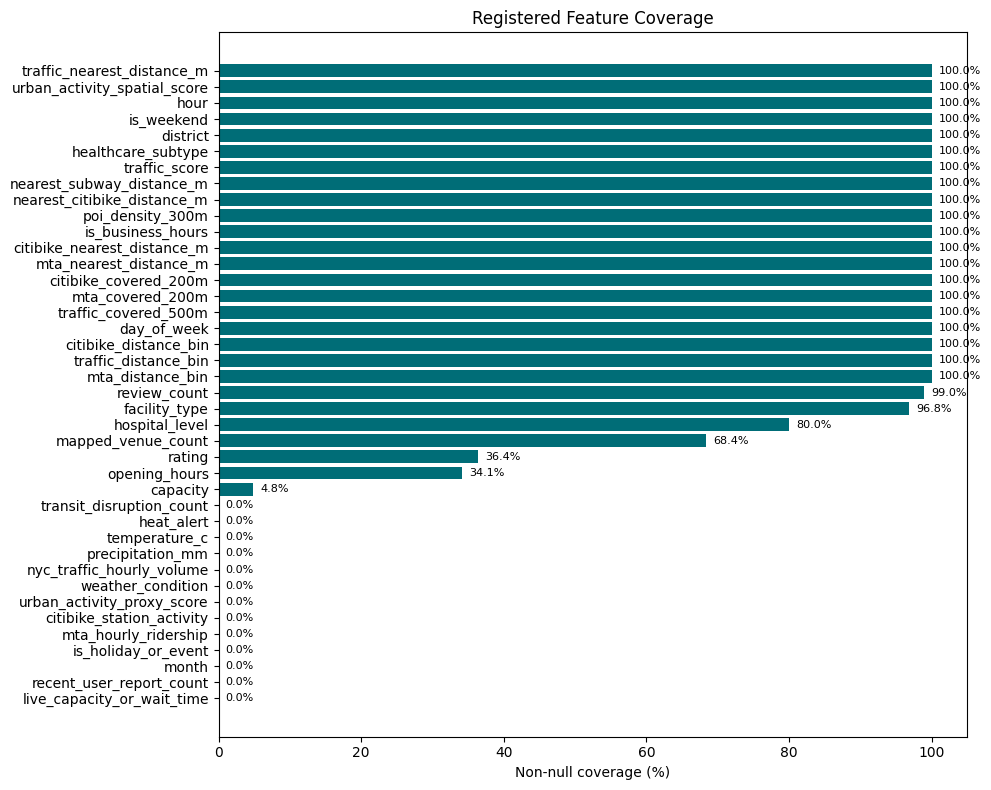

In [7]:

plot_df = feature_coverage.sort_values('coverage_pct', ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['feature'], plot_df['coverage_pct'], color='#006D77')
ax.set_xlabel('Non-null coverage (%)')
ax.set_title('Registered Feature Coverage')
ax.set_xlim(0, 105)
for idx, value in enumerate(plot_df['coverage_pct']):
    ax.text(value + 1, idx, f'{value:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()


In [8]:

# 静态低覆盖率特征来源溯源：venue 级口径，避免按 7 天小时样本重复计数。
low_cov_features = ['capacity', 'icu_capacity', 'cms_hospital_type', 'cms_rating', 'rating', 'opening_hours']
display(venue_feature_coverage[venue_feature_coverage['feature'].isin(low_cov_features)])

cap_venues = training_frame[training_frame['capacity'].notna()][['venue_id', 'place_title', 'prediction_group_id']].drop_duplicates()
print(f"capacity 有值的 venue 数: {len(cap_venues)}")
display(cap_venues)

cap_rows = training_frame[training_frame['capacity'].notna()]
print(f"capacity 有值的训练行数: {len(cap_rows)}")
for vid, grp in cap_rows.groupby('venue_id'):
    print(f"  venue_id={vid}  rows={len(grp)}  days={grp['day_of_week'].nunique()}  hours={grp['hour'].nunique()}")

rating_static = venue_feature_coverage.loc[venue_feature_coverage['feature'].eq('rating')].iloc[0]
print(f"rating venue 级非空: {int(rating_static['non_null_rows'])}/{int(rating_static['total_rows'])} ({rating_static['coverage_pct']:.1f}%)")
print(f"rating 训练行级非空: {training_frame['rating'].notna().sum()}/{len(training_frame)} ({training_frame['rating'].notna().mean()*100:.1f}%)")


,feature,scope,dtype,non_null_rows,total_rows,coverage_pct,status
2,rating,venue_static,float,395,1086,36.4,ok
3,opening_hours,venue_static,category,370,1086,34.1,ok
13,capacity,venue_static,float,52,1086,4.8,ok
14,icu_capacity,venue_static,float,52,1086,4.8,ok
17,cms_hospital_type,venue_static,category,57,1086,5.2,ok
18,cms_rating,venue_static,category,57,1086,5.2,ok


capacity 有值的 venue 数: 4


,venue_id,place_title,prediction_group_id
7645,654b6548607b4d6157b71a80ef5612cef41b,New York Eye and Ear Infirmary of Mount Sinai ...,ChIJFWtGP55ZwokRUoNXrEPdYmI
7646,b5c44d82affbf77588c85d8c5aea3e5549a3,New York Eye and Ear Infirmary of Mount Sinai ...,ChIJFWtGP55ZwokRUoNXrEPdYmI
8293,42192b4980e3fa1b5f39121fad90876a0b25,Downtown Pharmacy,ChIJz383mCJawokRUoZ_t0ZUvwA
8420,f65915d88909a8b328b89cd8e5383a91943a,Memorial Sloan Kettering Cancer Center New Yor...,ChIJBdNursNYwokRqcBjfvi9FiA


capacity 有值的训练行数: 546
  venue_id=42192b4980e3fa1b5f39121fad90876a0b25  rows=126  days=7  hours=18
  venue_id=654b6548607b4d6157b71a80ef5612cef41b  rows=126  days=7  hours=18
  venue_id=b5c44d82affbf77588c85d8c5aea3e5549a3  rows=126  days=7  hours=18
  venue_id=f65915d88909a8b328b89cd8e5383a91943a  rows=168  days=7  hours=24
rating venue 级非空: 395/1086 (36.4%)
rating 训练行级非空: 14307/22645 (63.2%)


## 6. 输入指标与输出指标说明

`role = input_feature` / `input_feature_optional` 是模型输入候选；`target` 是训练标签；`model_output` 是后续前端或模型服务应输出的字段。


In [9]:
display(io_dictionary)
display(io_dictionary.groupby('source_group').size() .reset_index(name='fields'))


,field,role,source_group,description
0,prediction_group_id,input_key,label_anchor,SerpAPI place id used as leakage-safe group key
1,venue_id,input_key,db_key,DB venue identifier mapped to a prediction group
2,day_of_week,input_feature,popular_times,Typical weekday from Google Popular Times cache
3,hour,input_feature,popular_times,"Hour of day, 0-23"
4,review_count,input_feature,serpapi_label,SerpAPI review count used as venue visibility ...
5,district,input_feature,db_direct,venues.district
6,rating,input_feature,db_direct,"venues.rating, backfilled from SerpAPI Place r..."
7,healthcare_subtype,input_feature,db_direct,healthcare_profiles.healthcare_category
8,opening_hours,input_feature,db_direct,venues.opening_hours
9,nearest_subway_distance_m,input_feature,db_spatial,Distance to nearest MTA subway station in meters


,source_group,fields
0,db_direct,4
1,db_key,1
2,db_spatial,3
3,derived,3
4,external_static,6
5,label_anchor,1
6,label_only,1
7,model_output,4
8,popular_times,2
9,serpapi_label,4


## 7. 训练表与 Baseline 输出样例


In [10]:

from IPython.display import HTML, FileLink

# 带样式的 HTML：固定列宽、自动换行
style = """
<style>
  table { border-collapse: collapse; width: auto; }
  th, td {
    max-width: 120px;
    padding: 4px 6px;
    font-size: 12px;
    word-wrap: break-word;
    white-space: normal;
    border: 1px solid #ddd;
  }
  th { background: #f5f5f5; position: sticky; top: 0; }
  tr:nth-child(even) { background: #fafafa; }
</style>
"""
html_content = style + training_frame.head(10).to_html(max_cols=None, index=False, classes='dataframe')
html_path = OUTPUT_DIR / 'training_frame_sample.html'
html_path.write_text(html_content)
print(FileLink(html_path))

display(seasonal_baseline.head)


/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project/Data+ML/test/6.28-7.3/output/training_frame_sample.html


<bound method NDFrame.head of      district day_of_week  hour  baseline_score
0    downtown      friday     0       37.333333
1    downtown      friday     1       26.888889
2    downtown      friday     2       42.444444
3    downtown      friday     3       37.666667
4    downtown      friday     4       46.888889
..        ...         ...   ...             ...
758       NaN   wednesday    19       41.625000
759       NaN   wednesday    20       34.625000
760       NaN   wednesday    21       14.625000
761       NaN   wednesday    22        0.000000
762       NaN   wednesday    23        0.000000

[763 rows x 4 columns]>

## 8. 模型训练、评估与预测曲线

这里展示脚本产出的回归指标、测试集预测样例和 12h 预测曲线。


In [11]:

display(model_metrics)
sample_preds = model_predictions.groupby('model_name').head(3).sort_values(['model_name', 'hour'])
display(sample_preds[['model_name', 'place_title', 'day_of_week', 'hour', 'busyness_score', 'predicted_score', 'predicted_level', 'serving_predicted_level', 'abs_error']])
display(prediction_curve.head())


,family_name,model_name,split,feature_set,feature_count,mae,rmse,r2,busy_level_accuracy,macro_f1,busy_recall
0,full_available,Ridge,train,"day_of_week,hour,is_weekend,district,review_co...",28,24.796,28.964,0.099,0.527,0.361,0.000
1,full_available,Ridge,val,"day_of_week,hour,is_weekend,district,review_co...",28,25.394,29.971,-0.058,0.481,0.298,0.000
2,full_available,Ridge,test,"day_of_week,hour,is_weekend,district,review_co...",28,25.310,29.428,0.085,0.500,0.319,0.000
3,full_available,RandomForestRegressor,train,"day_of_week,hour,is_weekend,district,review_co...",28,1.893,3.411,0.988,0.963,0.958,0.907
4,full_available,RandomForestRegressor,val,"day_of_week,hour,is_weekend,district,review_co...",28,16.962,22.341,0.412,0.673,0.557,0.155
5,full_available,RandomForestRegressor,test,"day_of_week,hour,is_weekend,district,review_co...",28,20.043,25.748,0.299,0.591,0.531,0.256
6,full_available,GradientBoostingRegressor,train,"day_of_week,hour,is_weekend,district,review_co...",28,14.021,18.077,0.649,0.718,0.598,0.136
7,full_available,GradientBoostingRegressor,val,"day_of_week,hour,is_weekend,district,review_co...",28,17.532,22.225,0.418,0.660,0.494,0.031
8,full_available,GradientBoostingRegressor,test,"day_of_week,hour,is_weekend,district,review_co...",28,18.365,23.202,0.431,0.641,0.534,0.132


,model_name,place_title,day_of_week,hour,busyness_score,predicted_score,predicted_level,serving_predicted_level,abs_error
6096,GradientBoostingRegressor,CVS,sunday,4,25,9.55,quiet,quiet,15.45
6097,GradientBoostingRegressor,CVS,sunday,5,35,9.55,quiet,quiet,25.45
6098,GradientBoostingRegressor,CVS,sunday,6,45,0.00,quiet,quiet,45.00
3048,RandomForestRegressor,CVS,sunday,4,25,10.99,quiet,quiet,14.01
3049,RandomForestRegressor,CVS,sunday,5,35,9.88,quiet,quiet,25.12
3050,RandomForestRegressor,CVS,sunday,6,45,12.33,quiet,quiet,32.67
0,Ridge,CVS,sunday,4,25,37.48,moderate,moderate,12.48
1,Ridge,CVS,sunday,5,35,36.84,moderate,moderate,1.84
2,Ridge,CVS,sunday,6,45,36.21,moderate,moderate,8.79


,model_name,venue_id,prediction_group_id,day_of_week,hour,predicted_score,predicted_level
0,Ridge,52603535436de064a28c7ff77ba27af50f4b,ChIJb-HkRuRYwokRF5qsEyxejyc,monday,8,48.41,moderate
1,Ridge,52603535436de064a28c7ff77ba27af50f4b,ChIJb-HkRuRYwokRF5qsEyxejyc,monday,9,47.78,moderate
2,Ridge,52603535436de064a28c7ff77ba27af50f4b,ChIJb-HkRuRYwokRF5qsEyxejyc,monday,10,47.15,moderate
3,Ridge,52603535436de064a28c7ff77ba27af50f4b,ChIJb-HkRuRYwokRF5qsEyxejyc,monday,11,46.51,moderate
4,Ridge,52603535436de064a28c7ff77ba27af50f4b,ChIJb-HkRuRYwokRF5qsEyxejyc,monday,12,45.88,moderate


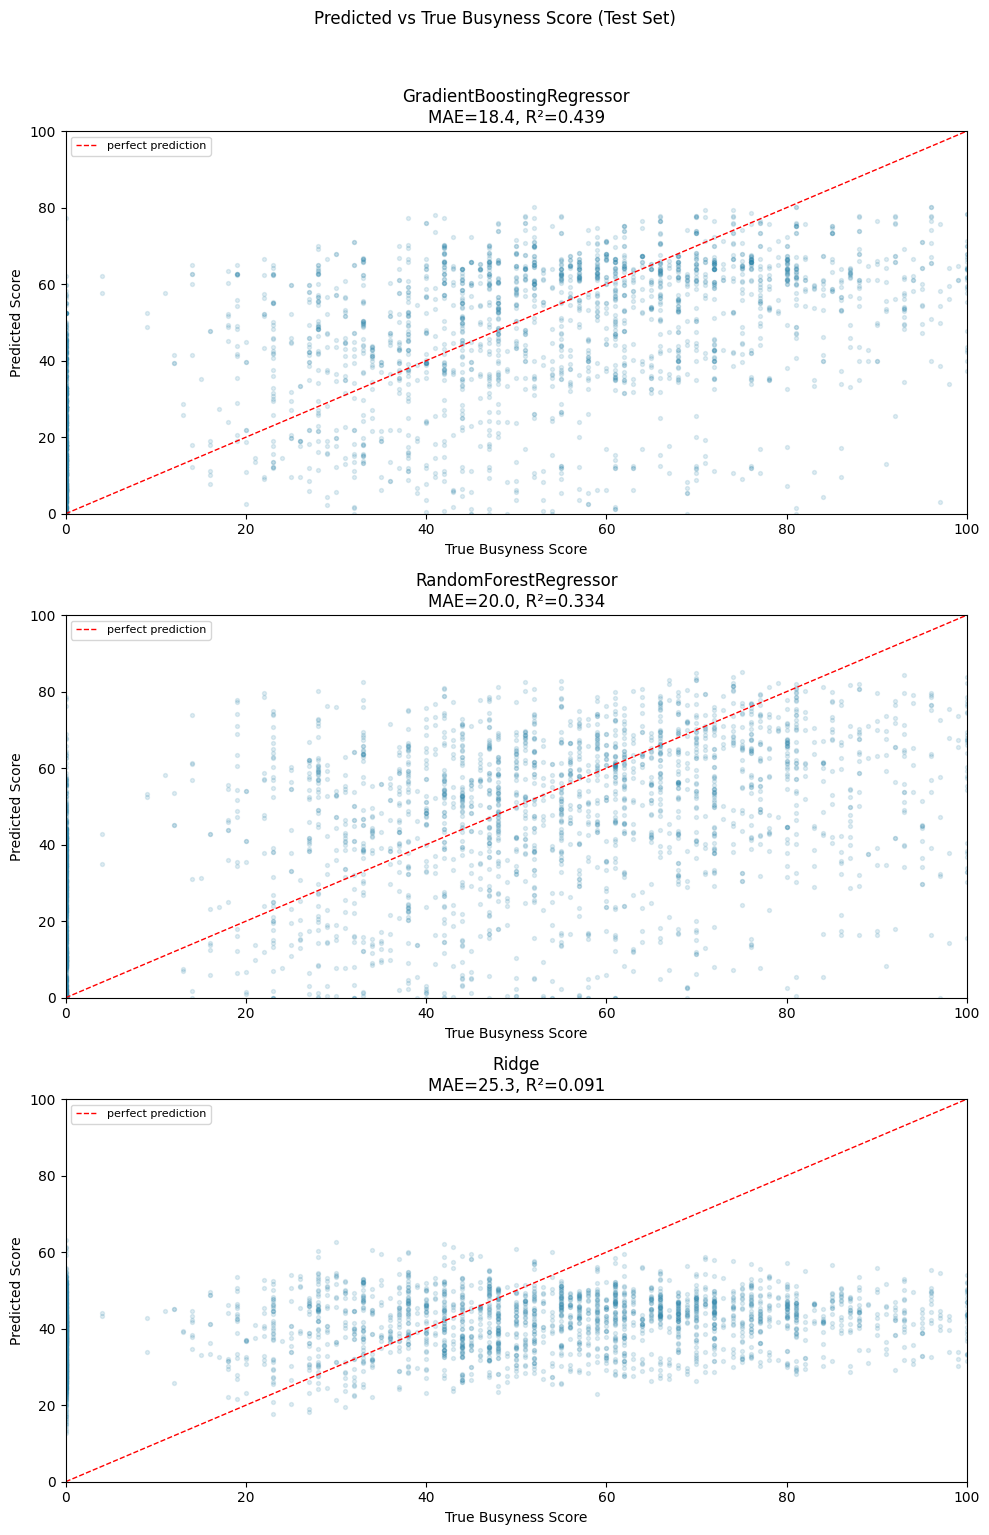

In [12]:

# 预测 vs 真实值散点图：每个模型的预测精度
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for ax, (model_name, grp) in zip(axes, model_predictions.groupby('model_name')):
    ax.scatter(grp['busyness_score'], grp['predicted_score'], alpha=0.15, s=8, color='#2E86AB')
    ax.plot([0, 100], [0, 100], 'r--', linewidth=1, label='perfect prediction')
    ax.set_xlabel('True Busyness Score')
    ax.set_ylabel('Predicted Score')
    ax.set_title(f'{model_name}\nMAE={grp["abs_error"].mean():.1f}, R²={grp["busyness_score"].corr(grp["predicted_score"])**2:.3f}')
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=8)
plt.suptitle('Predicted vs True Busyness Score (Test Set)', y=1.02)
plt.tight_layout()
plt.show()


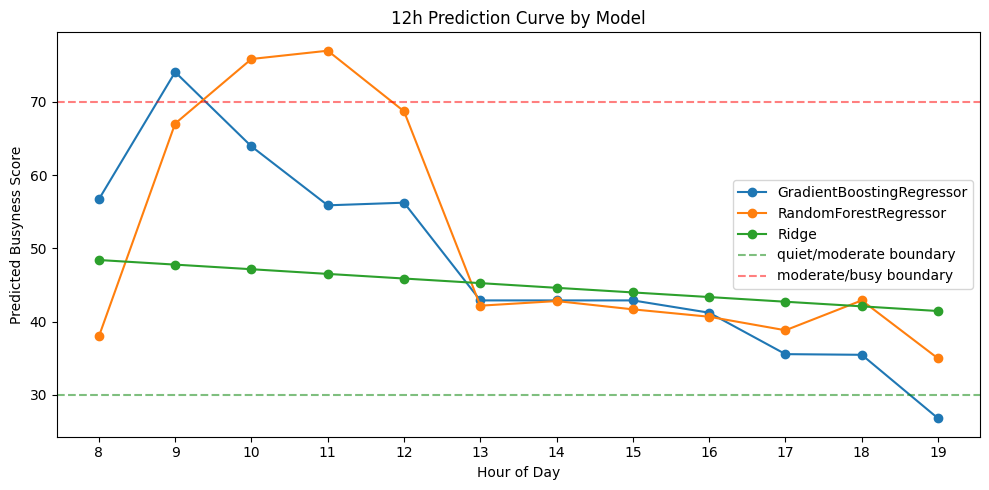

In [13]:

# 预测曲线折线图：每个模型的 12h 预测走势
fig, ax = plt.subplots(figsize=(10, 5))
for model_name, grp in prediction_curve.groupby('model_name'):
    ax.plot(grp['hour'], grp['predicted_score'], marker='o', label=model_name)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Predicted Busyness Score')
ax.set_title('12h Prediction Curve by Model')
ax.set_xticks(range(8, 20))
ax.axhline(30, color='green', linestyle='--', alpha=0.5, label='quiet/moderate boundary')
ax.axhline(70, color='red', linestyle='--', alpha=0.5, label='moderate/busy boundary')
ax.legend()
plt.tight_layout()
plt.show()


### 8.1 预测类别视图

上一张折线图展示 `predicted_score` 的数值变化；下面把同一条 12h 曲线转换成 `quiet / moderate / busy` 类别。

脚本会从 test set 中自动选择 12 小时内预测等级变化最多、分数跨度最大的 venue/day 样本，用于展示分类视角下的预测波动。


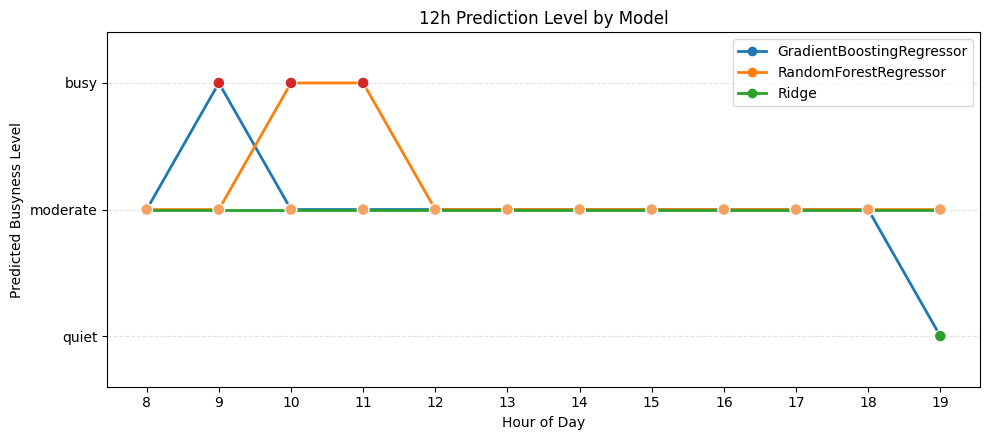

,model_name,predicted_level,hours,count
0,GradientBoostingRegressor,busy,9,1
1,GradientBoostingRegressor,moderate,"8, 10, 11, 12, 13, 14, 15, 16, 17, 18",10
2,GradientBoostingRegressor,quiet,19,1
3,RandomForestRegressor,busy,"10, 11",2
4,RandomForestRegressor,moderate,"8, 9, 12, 13, 14, 15, 16, 17, 18, 19",10
5,Ridge,moderate,"8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19",12


In [14]:
# 预测曲线类别图：展示每个小时最终落入 quiet / moderate / busy 哪一档
level_order = ['quiet', 'moderate', 'busy']
level_to_y = {level: idx for idx, level in enumerate(level_order)}
level_colors = {'quiet': '#2CA02C', 'moderate': '#F4A261', 'busy': '#D62728'}
curve_levels = prediction_curve.copy()
curve_levels['level_y'] = curve_levels['predicted_level'].map(level_to_y)

fig, ax = plt.subplots(figsize=(10, 4.5))
for model_name, grp in curve_levels.groupby('model_name'):
    grp = grp.sort_values('hour')
    ax.plot(grp['hour'], grp['level_y'], marker='o', linewidth=2, label=model_name)
    ax.scatter(
        grp['hour'],
        grp['level_y'],
        s=70,
        c=grp['predicted_level'].map(level_colors),
        edgecolor='white',
        linewidth=0.8,
        zorder=3,
    )

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Predicted Busyness Level')
ax.set_title('12h Prediction Level by Model')
ax.set_xticks(range(8, 20))
ax.set_yticks(range(len(level_order)))
ax.set_yticklabels(level_order)
ax.set_ylim(-0.4, len(level_order) - 0.6)
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

level_summary = (
    curve_levels
    .groupby(['model_name', 'predicted_level'])
    .agg(hours=('hour', lambda values: ', '.join(map(str, values))), count=('hour', 'size'))
    .reset_index()
)
display(level_summary)


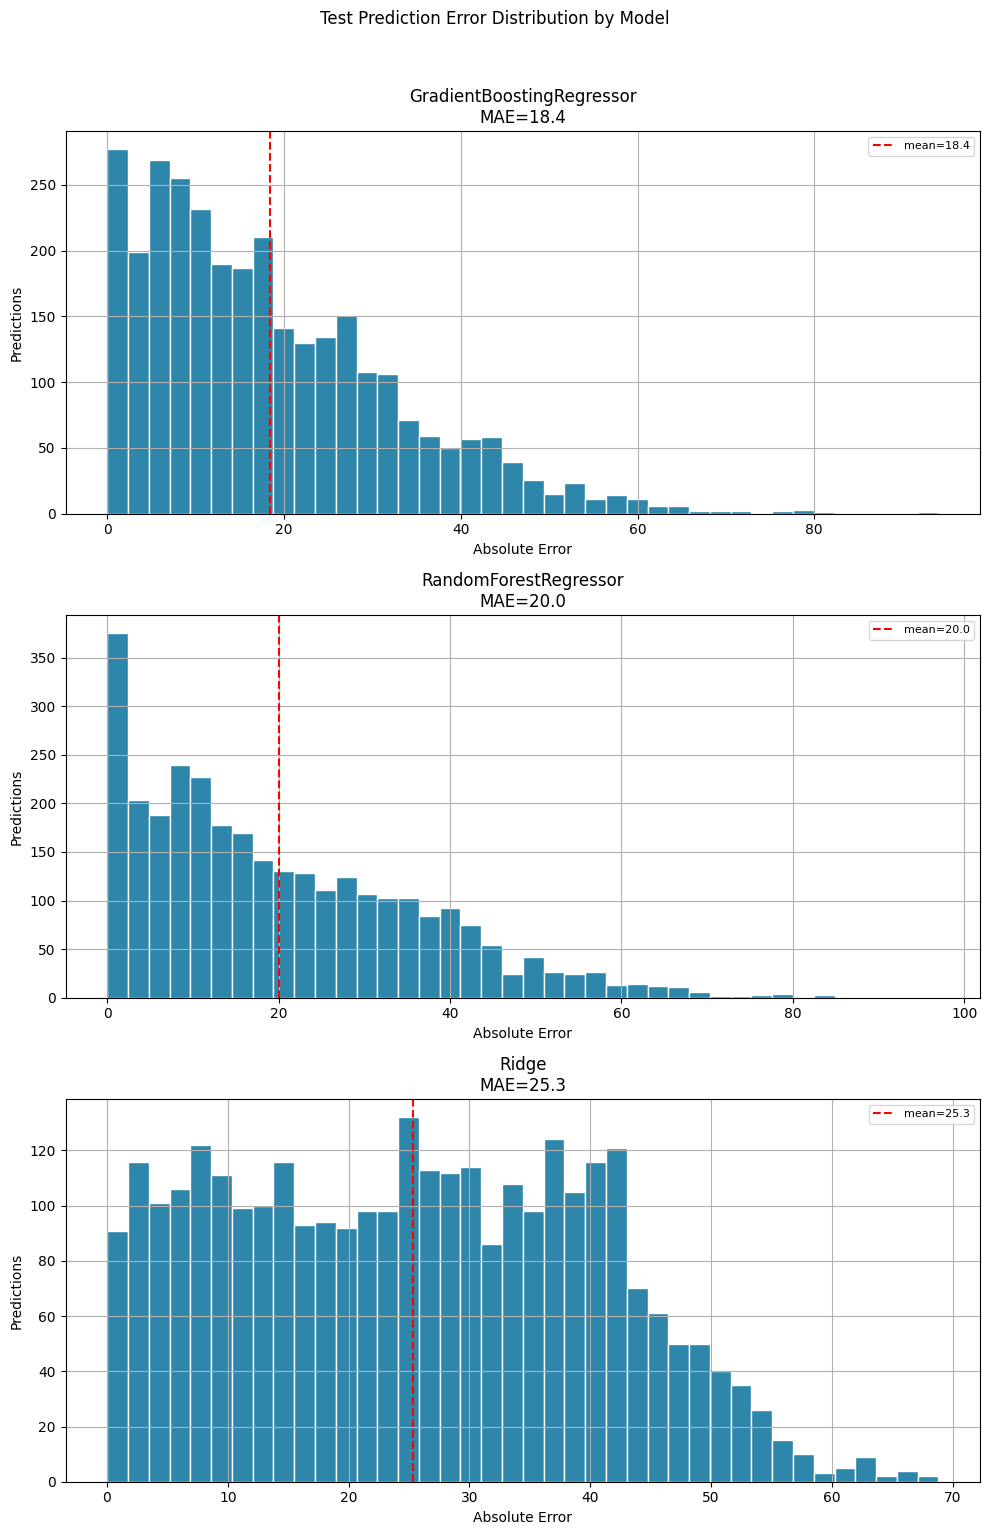

In [15]:
 
# 测试集预测误差分布：每个模型的 abs_error 分布
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
for ax, (model_name, grp) in zip(axes, model_predictions.groupby('model_name')):
    grp['abs_error'].hist(bins=40, ax=ax, color='#2E86AB', edgecolor='white')
    ax.set_title(f'{model_name}\nMAE={grp["abs_error"].mean():.1f}')
    ax.set_xlabel('Absolute Error')
    ax.set_ylabel('Predictions')
    ax.axvline(grp['abs_error'].mean(), color='red', linestyle='--', label=f'mean={grp["abs_error"].mean():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('Test Prediction Error Distribution by Model', y=1.02)
plt.tight_layout()
plt.show()
